In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load the data
config = pd.read_csv('experiments/models/dataset_quality/experiment_config.csv')
results = pd.read_csv('experiments/results/dataset_quality.csv')

In [3]:
results['experiment'] = results['model_id'].apply(lambda x: x.split('_')[-1])
results['experiment'] = results['experiment'].astype(int)

In [4]:
# Merge the results and config DataFrames on the 'experiment' column
df = pd.merge(results, config, on='experiment', suffixes=('_results', '_config'))

In [5]:
df['model'] = df['model_id'].apply(lambda x: x.split('_')[0])
# Create a new column 'dataset_quantity' as the product of 'dataset_size', 'train_size', and 'val_size'
df['train_size'] = df['train_size']*df['dataset_size']
df['val_size'] = df['val_size']*df['dataset_size']
df['dataset_size'] = df['train_size']+df['val_size']

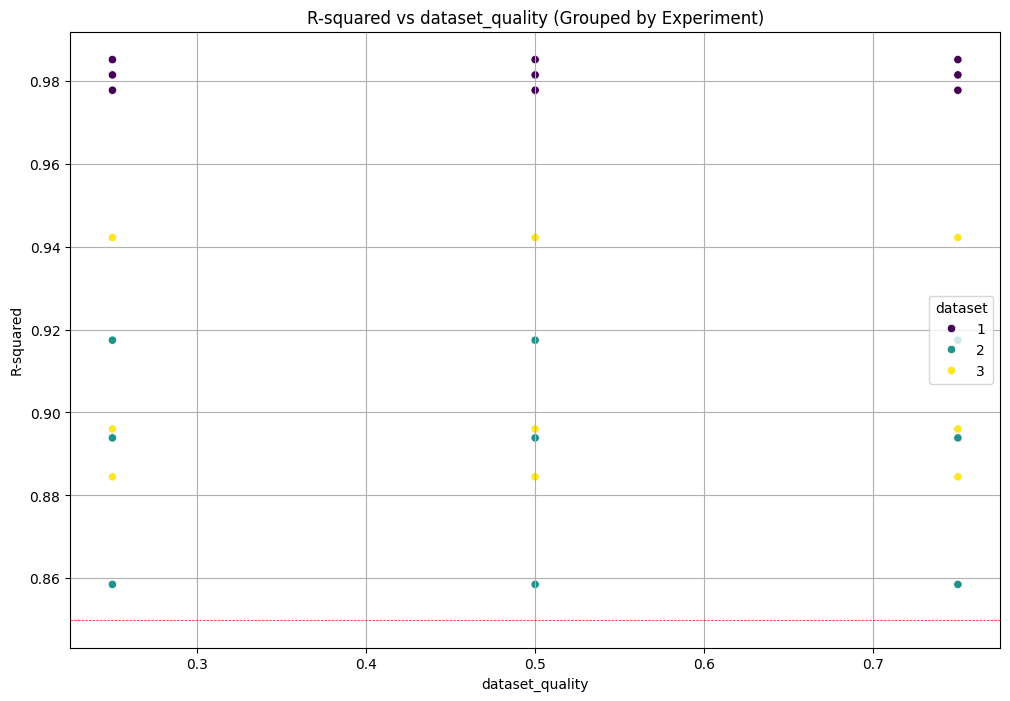

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the DataFrame with model == 'yolov5lu'
filtered_df = df[df['model'] == 'yolov5su']

# Group by 'experiment' and select the observation with the highest R-squared value
filtered_df = filtered_df.loc[filtered_df.groupby('experiment')['r_squared'].idxmax()]

# set r-squared <0 to 0
filtered_df.loc[filtered_df['r_squared'] < 0, 'r_squared'] = 0

# Sort by dataset size
filtered_df = filtered_df.sort_values(by='dataset_quality')

# Create a scatter plot with 'dataset_size' on the x-axis and 'r_squared' on the y-axis
plt.figure(figsize=(12, 8))
sns.scatterplot(data=filtered_df, x='dataset_quality', y='r_squared', hue='dataset', palette='viridis')

# Plot a red line at y = 0.85
plt.axhline(y=0.85, color='red', linestyle='--', linewidth=0.5)

plt.xlabel('dataset_quality')
plt.ylabel('R-squared')
plt.title('R-squared vs dataset_quality (Grouped by Experiment)')
plt.grid(True)

plt.show()